# Negative Triangularity Analysis

In [1]:
# %% Import JAX and enable 64-bit precision
import jax
jax.config.update("jax_enable_x64", True)

In [ ]:
# %% Import other libraries
import equinox as eqx
import interpax
import diffrax
import optimistix as optx

import numpy as np
import jax.numpy as jnp
import jax.tree_util as jtu
from dataclasses import dataclass
from functools import partial
import numpy as np
from collections import namedtuple
from typing import NamedTuple
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

from netCDF4 import Dataset

from jaxtyping import ArrayLike, Real
from tqdm.notebook import tqdm

import pickle

In [3]:
# %% Load my own libraries
%load_ext autoreload
%autoreload 2
from c1lgkt.jax.fields.equilibrium import Equilibrium
from c1lgkt.jax.fields.clebsch import ClebschMappingBuilder
from c1lgkt.jax.fields.field_providers import EikonalFieldProvider, ZonalFieldProvider
import c1lgkt.jax.particles.particle_motion as particle_motion
import c1lgkt.jax.particles.particle_tools as particle_tools
from c1lgkt.jax.analysis.wba import wba_weights


In [4]:
# %% Load equilibrium and set up clebsch mapping
eq = Equilibrium.from_gfile('./scratch/data/g193802.04490')

clebsch_builder = ClebschMappingBuilder()
# Check if the mapping file exists
if os.path.isfile('./scratch/outputs/theta_map_193802.eqx'):
    print('Loading existing theta map...')
    theta_map = clebsch_builder.load_theta_map('./scratch/outputs/theta_map_193802.eqx')
else:
    print('Building new theta map...')
    theta_map = clebsch_builder.build_theta_map(eq)
    eqx.tree_serialise_leaves('./scratch/outputs/theta_map_193802.eqx', theta_map)
# Build Clebsch representation
if os.path.isfile('./scratch/outputs/clebsch_193802.eqx'):
    print('Loading existing Clebsch representation...')
    clebsch = clebsch_builder.load_clebsch('./scratch/outputs/clebsch_193802.eqx')
else:
    print('Building new Clebsch representation...')
    clebsch = clebsch_builder.build_clebsch(theta_map, eq)
    eqx.tree_serialise_leaves('./scratch/outputs/clebsch_193802.eqx', clebsch)

Loading existing theta map...
Loading existing Clebsch representation...


Text(0.5, 1.0, 'p193802.04490')

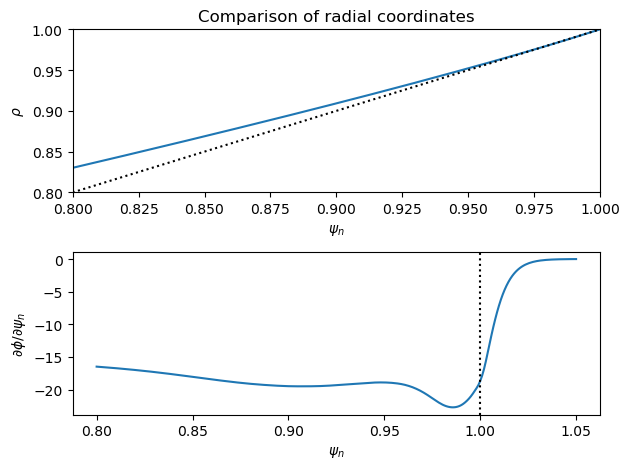

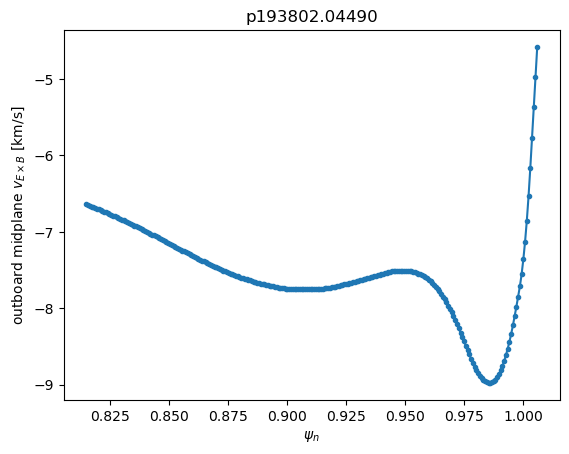

In [5]:
# %% Set up fields

# Load Er from pfile
zonal_fields = ZonalFieldProvider.from_pfile('./scratch/data/p193802.04490', eq)
interp_phi_scaled = interpax.Interpolator1D(zonal_fields.interp_phi.x, zonal_fields.interp_phi.f*1.5, method='cubic2')
zonal_fields = ZonalFieldProvider(interp_phi=interp_phi_scaled, interp_apar=zonal_fields.interp_apar)

# Compute the toroidal flux coordinate for comparison with stewart et al.
psinorm = np.linspace(0.0, 1.0, 256)
mids = (psinorm[1:] + psinorm[:-1]) * 0.5
# Use midpoint rule to compute the toroidal flux
q_clebsch = (clebsch.interp_alpha(mids*eq.psix, jnp.full_like(mids, jnp.pi)) - clebsch.interp_alpha(mids*eq.psix, jnp.full_like(mids, -jnp.pi))) / (2 * jnp.pi)
torflux = np.concatenate([np.array([0.0]), np.cumsum(q_clebsch)])
rhonorm = np.sqrt(torflux / torflux[-1])

plt.figure()

plt.subplot(211)
plt.plot(psinorm, rhonorm)
plt.plot([0.8, 1.0], [0.8, 1.0], ls=':', c='k')
plt.xlim(0.8, 1.0)
plt.ylim(0.8, 1.0)
plt.title('Comparison of radial coordinates')
plt.xlabel(R'$\psi_n$')
plt.ylabel(R'$\rho$')


plt.subplot(212)
psi_plot = jnp.linspace(eq.psix*0.8, eq.psix*1.05, 256)
phi_plot = -zonal_fields.interp_phi(psi_plot, dx=1)
plt.plot(psi_plot/eq.psix, phi_plot)
plt.axvline(1.0, ls=':', c='k')
plt.xlabel(R'$\psi_n$')
plt.ylabel(R'$\partial\phi / \partial \psi_n$')

plt.tight_layout()

plt.figure()

r_plot = jnp.linspace(2.25, 2.303, 256)
psi_plot_2 = eq.interp_psi(r_plot, jnp.full_like(r_plot, eq.zaxis))
bv_plot = eq.compute_bv(r_plot, jnp.full_like(r_plot, eq.zaxis))
modb_plot = jnp.linalg.norm(bv_plot, axis=0)
dpsi_dr = eq.interp_psi(r_plot, jnp.full_like(r_plot, eq.zaxis), dx=1)
plt.plot(psi_plot_2/eq.psix, -zonal_fields.interp_phi(psi_plot_2, dx=1)*dpsi_dr / modb_plot, marker='.')
plt.xlabel(R'$\psi_n$')
plt.ylabel(R"outboard midplane $v_{E\times B}$ [km/s]")
plt.title('p193802.04490')



In [6]:
coefs = jnp.zeros((1, 4, 6))
# Te ~ 0.25 keV at rho ~ 0.95. We want e phi / Te ~ ntilde / n0 ~ 3e-2; phi is in kV
# This ends up being around 7.5 V
coefs = coefs.at[0, 0, 0].set(0.25*3e-2)

eikonal_field = EikonalFieldProvider(
    theta_map,
    clebsch,
    # n = 6 leads to k_\theta of about 0.176 rad/cm at the OMP
    jnp.array([6], dtype=int),
    # taking f about 25 kHz
    jnp.array([2*jnp.pi*28.0]),
    # Perturbation is centered around rho = 0.95
    jnp.array([0.94*eq.psix]),
    # Width is about 0.05 in normalized psi
    jnp.array([0.045*eq.psix]),
    # Mode is peaked at the outer midplane
    jnp.array([0.0]),
    # Poloidal extent of the mode; somewhat arbitrary for now
    jnp.array([jnp.pi]),
    # Amplitude of the mode; see earlier
    coefs
    )

10.98458969786641 2.5


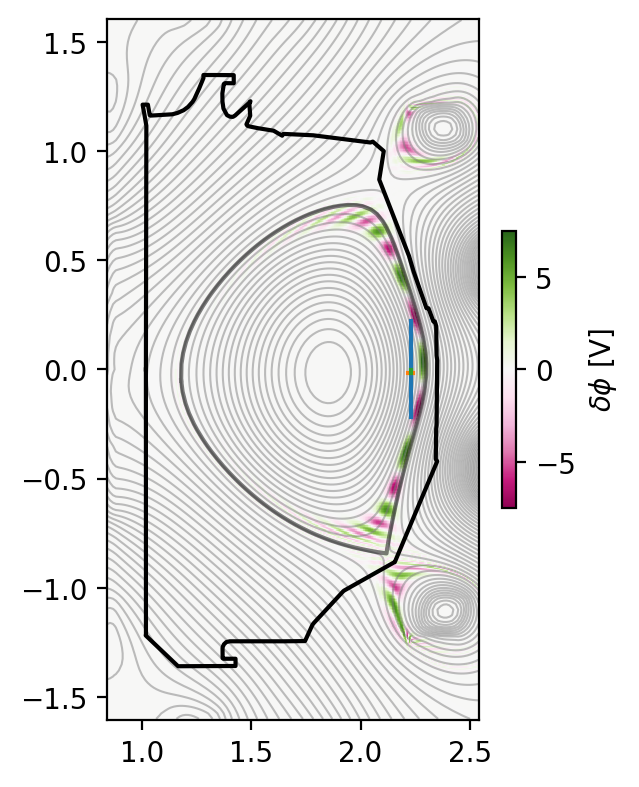

In [7]:
# %% Plot the equilibrium and the Clebsch representation
fig = plt.figure(figsize=(3, 6), dpi=200)

ax = plt.subplot(111)

eq.plot_magnetic_geometry(ax, alpha=0.5)

rgrid = np.linspace(eq.rmin, eq.rmax, 512)
zgrid = np.linspace(eq.zmin, eq.zmax, 512)
rplot, zplot = np.meshgrid(rgrid, zgrid, indexing='ij')

theta = theta_map(rplot.ravel(), zplot.ravel()).reshape(rplot.shape)
psi = eq.interp_psi(rplot.ravel(), zplot.ravel()).reshape(rplot.shape)

alpha = clebsch.interp_alpha(psi.ravel(), theta.ravel()).reshape(psi.shape)

psi_ev, ff_ev = eq.compute_psi_and_ff(rplot.ravel(), zplot.ravel())
varphi_fluct = jnp.full_like(rplot.ravel(), 0.0)
phi_fluct, apar_fluct = eikonal_field(0.005, rplot.ravel(), varphi_fluct, zplot.ravel(), psi_ev)

phi_max = jnp.max(jnp.abs(phi_fluct))*1e3

pc = ax.pcolormesh(rplot, zplot, phi_fluct.reshape(psi.shape)*1e3, shading='auto', cmap='PiYG', vmin=-phi_max, vmax=phi_max)
plt.colorbar(pc, label=R'$\delta\phi$ [V]', shrink=0.3)

## From Stewart+ PPCF 2025 fig. 4, this is maybe the right poloidal wavelength on the OMP
l_poloidal = (2 * jnp.pi / 0.143) / 100.0
l_radial = 2.5 / 100.0
print((l_poloidal/4)*100, l_radial*100)
ax.plot([2.23, 2.23], [-l_poloidal/2, l_poloidal/2])
ax.plot([2.23-l_radial/2, 2.23+l_radial/2], [eq.zaxis, eq.zaxis])
ax.plot([2.23, 2.23], [eq.zaxis, eq.zaxis+0.01])

In [44]:
# %% Load the puncture data

# Number of particles
nump = 96
# Dummy initial puncture data to accumulate into; note this is the older format
y0 = particle_motion.PusherState.empty(nump)

ppuncs = particle_tools.PunctureData.empty_list_like(y0)
npuncs = particle_tools.PunctureData.empty_list_like(y0)
npuncs_poloidal = particle_tools.PunctureData.empty_list_like(y0)
ppuncs_poloidal = particle_tools.PunctureData.empty_list_like(y0)



for i in range(0,1):
    with open(f'./scratch/outputs/nt/puncs_long_pair_{i}.pkl', 'rb') as f:
        ppuncs_i, npuncs_i = pickle.load(f)
        #ppuncs_i, npuncs_i, ppuncs_pi, npuncs_pi = pickle.load(f)
    
    # Accumulate punctures
    ppuncs = jax.tree.map(lambda *xs: np.concatenate(xs), ppuncs, ppuncs_i)
    npuncs = jax.tree.map(lambda *xs: np.concatenate(xs), npuncs, npuncs_i)
    #ppuncs_poloidal = jax.tree.map(lambda *xs: np.concatenate(xs), ppuncs_poloidal, ppuncs_pi)
    #npuncs_poloidal = jax.tree.map(lambda *xs: np.concatenate(xs), npuncs_poloidal, npuncs_pi)

In [48]:
# %% Compute rotation numbers

%matplotlib qt

omega_b = np.zeros(nump)
r_avg = np.zeros(nump)
iota = np.zeros(nump)
total_phase = np.zeros(nump)

omega_eikonal = 2*jnp.pi*27.0
n_eikonal = 6

for k in range(nump):
    punc = ppuncs[k]
    
    r_p, varphi_p, z_p, upar_p, mu_p = punc.yp
    print(len(r_p))
    phase = n_eikonal*varphi_p - (punc.tp*omega_eikonal) # pyright: ignore
    total_phase[k] = phase[-1] - phase[0]

    iota[k] = np.sum(wba_weights(len(phase)-1) * np.diff(phase) / n_eikonal)
    r_avg[k] = np.sum(wba_weights(len(phase)) * r_p)
    omega_b[k] = 2*np.pi / (np.sum(wba_weights(len(phase)-1) * np.diff(punc.tp)))


psi_avg = eq.interp_psi(r_avg, jnp.full_like(r_avg, eq.zaxis))
plt.figure()
plt.subplot(211)
plt.scatter(psi_avg/eq.psix, iota)
plt.subplot(212)
plt.scatter(psi_avg/eq.psix, omega_b)

9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
8
9
9
9
9
9
9
8
9
9
9
9
9
9
8
9
9
9
9
9
9
8
9
9
9
9
9
9
8
9
9
9
9
9
9
8
9
9
9
9
9
9
9
9
9
9


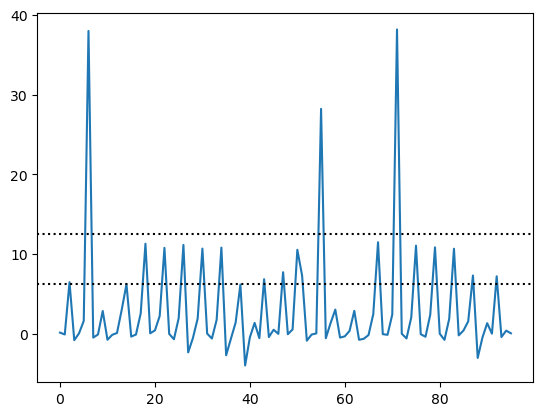

In [37]:
plt.figure()
plt.plot(total_phase)
plt.axhline(2*np.pi, ls=':', c='k')
plt.axhline(4*np.pi, ls=':', c='k')

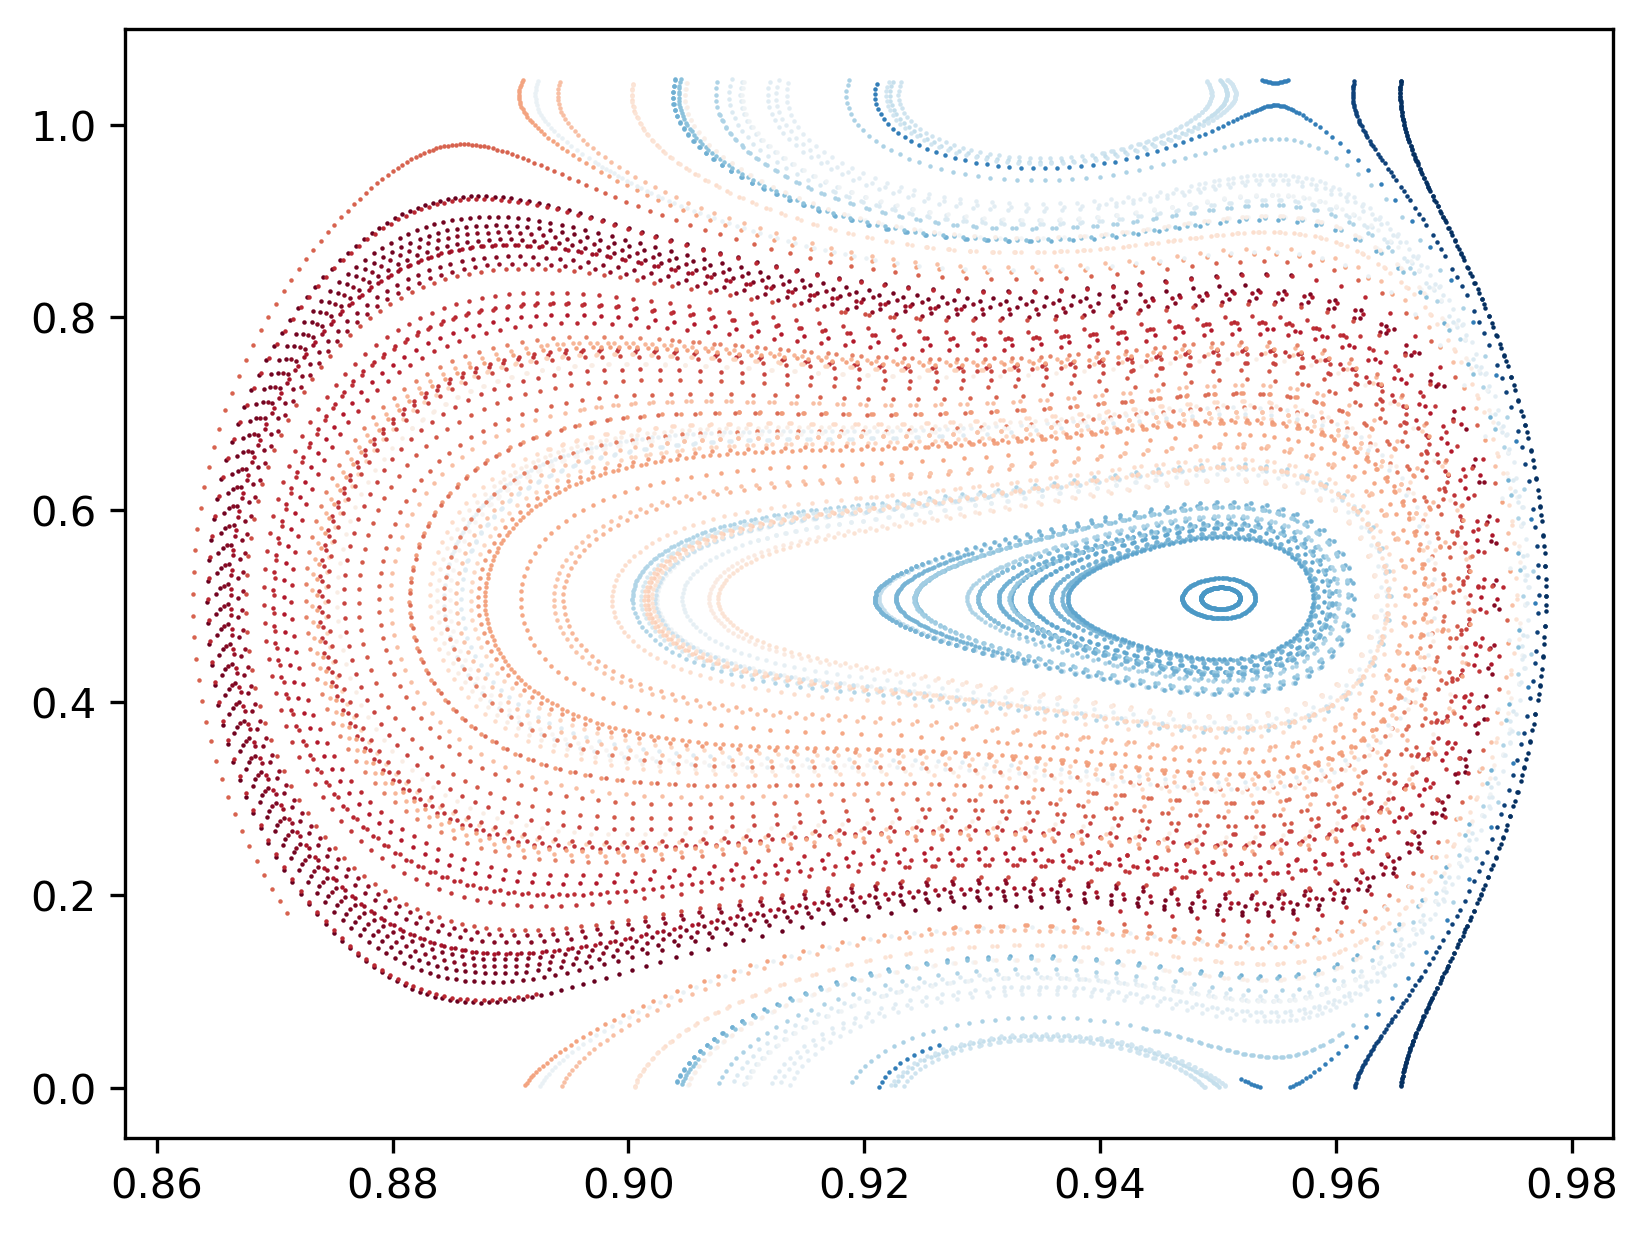

In [30]:
# %% Plot Poincare section


pp = particle_motion.elec

plt.figure(dpi=300)

ax = plt.subplot(111)
#eq.plot_magnetic_geometry(ax, alpha=0.2)
for k in range(nump):
    punc = ppuncs[k]
    r_p, varphi_p, z_p, upar_p, mu_p = punc.yp
    phase = n_eikonal*varphi_p - (punc.tp*omega_eikonal) # pyright: ignore
    psi_p = eq.interp_psi(r_p, z_p)

    color = mpl.cm.RdBu((psi_avg[k] - np.min(psi_avg))/(np.max(psi_avg) - np.min(psi_avg)))

    plt.scatter(psi_p / eq.psix, np.mod(phase, 2*np.pi)/n_eikonal, s=9.0*(72/100.0)**2, lw=0.0, marker='.', color=color)

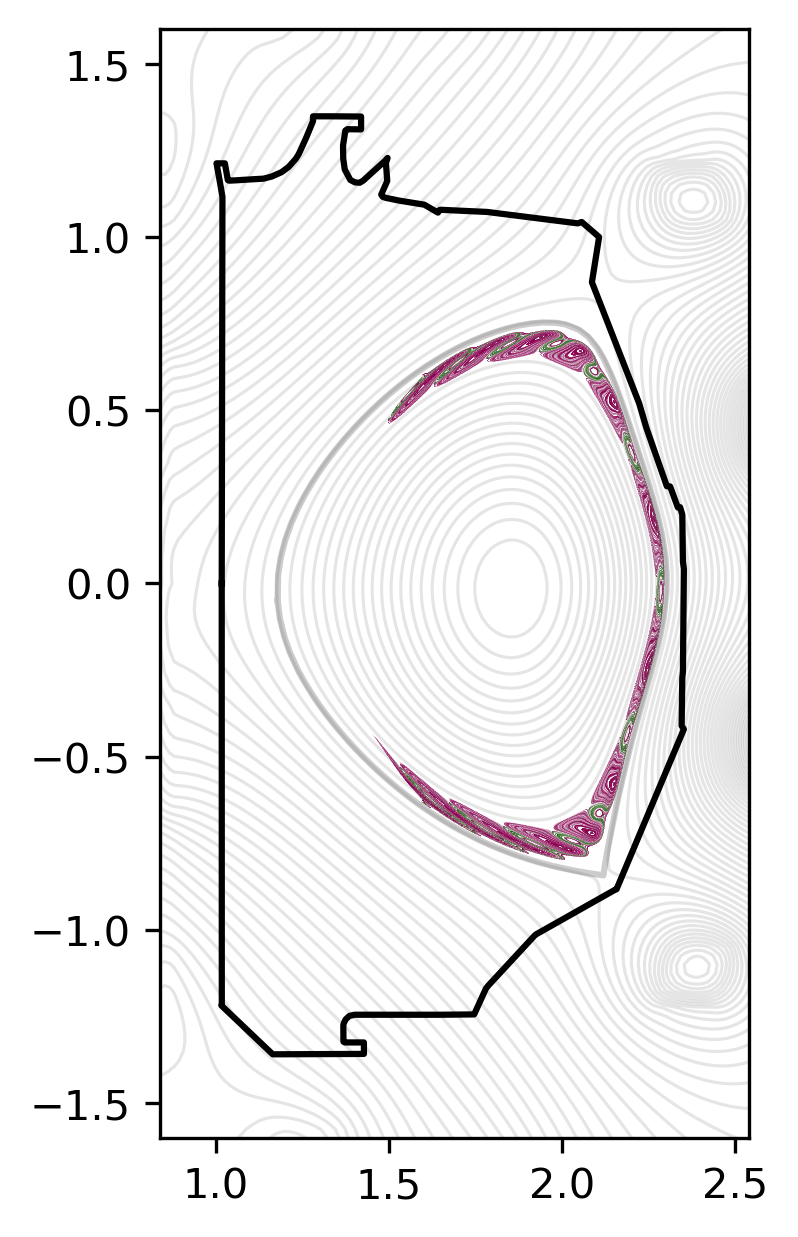

In [41]:
# %% Plot poloidal section

%matplotlib inline

plt.figure(dpi=300)

ax = plt.subplot(111)
eq.plot_magnetic_geometry(ax, alpha=0.2)

for k in range(nump):
    punc = ppuncs_poloidal[k]
    r_p, varphi_p, z_p, upar_p, mu_p = punc.yp

    color = mpl.cm.PiYG((total_phase[k] > 2*np.pi) * 1.0 * (total_phase[k] < 4*np.pi))

    plt.scatter(r_p, z_p, s=(72/300.0)**2, lw=0.0, marker='.', color=color, alpha=0.25)